In [1]:
import nest_asyncio
nest_asyncio.apply()  # Cho phép nest event loop trong Jupyter

import sys
sys.path.insert(0, "/home/duoc/workflow/api")  # thư mục chứa folder app/
print("Cấu hình sys.path thành công! Thư mục hiện tại:")
import os
os.chdir("/home/duoc/workflow/api")  # Thêm dòng này TRƯỚC khi import app

Cấu hình sys.path thành công! Thư mục hiện tại:


In [2]:
# =══════════════════════════════════════════════════════
# CELL: CHECK DB & GET REAL BRAND ID
# =══════════════════════════════════════════════════════
import asyncio
from sqlalchemy import text
from app.db import AsyncSessionLocal

async def check_database_and_get_brand():
    print("🔍 Đang kết nối tới database để kiểm tra dữ liệu...")
    async with AsyncSessionLocal() as db:
        try:
            # 1. Kiểm tra tổng số lượng brand đang có
            count_query = text("SELECT COUNT(*) FROM brands WHERE deleted_at IS NULL")
            count_result = await db.execute(count_query)
            total_brands = count_result.scalar()
            print(f"📊 Tổng số Brand đang hoạt động trong DB: {total_brands}")
            
            if total_brands == 0:
                print("⚠️ Cảnh báo: Không tìm thấy Brand nào trong bảng `brands`!")
                return None
            
            # 2. Lấy danh sách 3 brand mới nhất để bạn lựa chọn
            select_query = text("""
                SELECT id, name, desired_tone, created_at 
                FROM brands 
                WHERE deleted_at IS NULL 
                ORDER BY created_at DESC 
                LIMIT 3
            """)
            result = await db.execute(select_query)
            brands = result.fetchall()
            
            print("\n📋 Danh sách Brand khả dụng:")
            print("-" * 60)
            for idx, brand in enumerate(brands, 1):
                print(f"{idx}. Tên: {brand.name}")
                print(f"   ID  : '{brand.id}'")
                print(f"   Tone: {brand.desired_tone}")
                print("-" * 60)
                
            # Trả về ID của brand đầu tiên để tự động gán vào test
            return str(brands[0].id)
            
        except Exception as e:
            print(f"❌ Lỗi kết nối hoặc truy vấn DB: {e}")
            return None

# Chạy hàm async trong môi trường Jupyter (đã có sẵn event loop)
target_brand_id = await check_database_and_get_brand()

if target_brand_id:
    print(f"\n✅ Đã tự động lưu ID để test: target_brand_id = '{target_brand_id}'")
else:
    print("\n❌ Không lấy được ID hợp lệ. Vui lòng kiểm tra lại cấu hình DB trong file .env")

🔍 Đang kết nối tới database để kiểm tra dữ liệu...
2026-06-21 21:40:08,367 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-21 21:40:08,367 INFO sqlalchemy.engine.Engine SELECT COUNT(*) FROM brands WHERE deleted_at IS NULL
2026-06-21 21:40:08,368 INFO sqlalchemy.engine.Engine [generated in 0.00043s] ()
📊 Tổng số Brand đang hoạt động trong DB: 1
2026-06-21 21:40:08,369 INFO sqlalchemy.engine.Engine 
                SELECT id, name, desired_tone, created_at 
                FROM brands 
                WHERE deleted_at IS NULL 
                ORDER BY created_at DESC 
                LIMIT 3
            
2026-06-21 21:40:08,370 INFO sqlalchemy.engine.Engine [generated in 0.00054s] ()

📋 Danh sách Brand khả dụng:
------------------------------------------------------------
1. Tên: string
   ID  : '4ed55b52-b72e-4721-8f24-0b2c6412d078'
   Tone: Chuyên nghiệp
------------------------------------------------------------
2026-06-21 21:40:08,372 INFO sqlalchemy.engine.Engine ROLLBACK

✅

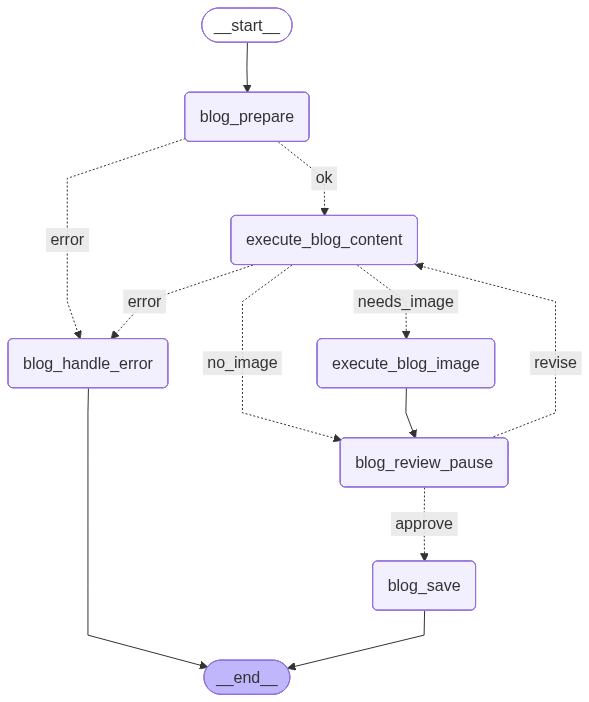


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
STARTING BLOG GRAPH — STREAMING EACH NODE
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

🟢 NODE: blog_prepare
2026-06-21 21:40:10,346 INFO sqlalchemy.engine.Engine BEGIN (implicit)


2026-06-21 21:40:10,346 INFO sqlalchemy.engine.Engine: BEGIN (implicit)


2026-06-21 21:40:10,374 INFO sqlalchemy.engine.Engine SELECT brands.id, brands.business_id, brands.metadata_info, brands.name, brands.purpose, brands.channels, brands.desired_tone, brands.target_audience, brands.website_url, brands.k1_brand_foundation, brands.k2_customer_insights, brands.k3_content_patterns, brands.k4_behavior_rules, brands.k5_examples, brands.k6_tone_analysis, brands.k7_vocabulary_rules, brands.taglines, brands.business_facts, brands.tone_funny_serious, brands.tone_formal_casual, brands.tone_respectful_irreverent, brands.tone_enthusiastic_matter_of_fact, brands.is_default, brands.created_at, brands.updated_at, brands.deleted_at 
FROM brands 
WHERE brands.id = ? AND brands.deleted_at IS NULL
 LIMIT ? OFFSET ?


2026-06-21 21:40:10,374 INFO sqlalchemy.engine.Engine: SELECT brands.id, brands.business_id, brands.metadata_info, brands.name, brands.purpose, brands.channels, brands.desired_tone, brands.target_audience, brands.website_url, brands.k1_brand_foundation, brands.k2_customer_insights, brands.k3_content_patterns, brands.k4_behavior_rules, brands.k5_examples, brands.k6_tone_analysis, brands.k7_vocabulary_rules, brands.taglines, brands.business_facts, brands.tone_funny_serious, brands.tone_formal_casual, brands.tone_respectful_irreverent, brands.tone_enthusiastic_matter_of_fact, brands.is_default, brands.created_at, brands.updated_at, brands.deleted_at 
FROM brands 
WHERE brands.id = ? AND brands.deleted_at IS NULL
 LIMIT ? OFFSET ?


2026-06-21 21:40:10,375 INFO sqlalchemy.engine.Engine [generated in 0.00094s] ('4ed55b52-b72e-4721-8f24-0b2c6412d078', 1, 0)


...

2026-06-21 21:40:10,391 INFO sqlalchemy.engine.Engine ROLLBACK


2026-06-21 21:40:10,391 INFO sqlalchemy.engine.Engine: ROLLBACK


✅ get_brand_prompt_by_id success | prompt length: 3757
⏱️  Elapsed: 0.048s | needs_image=True
------------------------------Bạn là chuyên gia sáng tạo nội dung đại diện cho thương hiệu: string
Định hướng hoạt động thương hiệu: Tăng trưởng kinh doanh và nhận diện thương hiệu
Đối tượng độc giả/Khách hàng mục tiêu cần hướng tới: Khách hàng mục tiêu


## 🛑 KHUNG LỆNH CẤM BẮT BUỘC (CRITICAL NEGATIVE CONSTRAINTS)
TẤT CẢ các điều khoản dưới đây là TUYỆT ĐỐI, nếu vi phạm bài viết sẽ bị hệ thống loại bỏ ngay lập tức:
- TUYỆT ĐỐI KHÔNG xuất hiện các từ ngữ sau trong bài viết: anh, đã, được
- TUYỆT ĐỐI KHÔNG lồng ghép các cụm từ: không gian ấm cúng / tinh thần thi đấu quyết tâm

## ĐỊNH HƯỚNG CỐT LÕI THƯƠNG HIỆU (K1 FOUNDATION)
# PURPOSE

The purpose of Mộc Quán is to provide a welcoming and welcoming  dining experience for customers.

# PERSONALITY

Mộc Quán presents itself as a friendly, enthusiastic  and welcoming place that values  values the presence  presence  and feedback  feedback  of  fr

2026-06-21 21:40:14,639 INFO httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"



📦 NODE OUTPUT: execute_blog_content
🔍 Key fields:
   needs_image: True
   publish_status: pending
   approved: False
   title: Mộc Quán – Điểm dừng chân ẩm thực hải sản tại Đà Nẵng 🌊🍤
📄 draft.content length: 1697
   draft.version: 1
   draft.metadata: {'type': 'blog_post', 'word_count': 374, 'images': ['Mộc Quán bên bờ biển Đà Nẵng, ánh hoàng hôn rực rỡ']}
💰 usage: {
      "total_tokens": 374,
      "total_cost": 0.0,
      "calls": [
            {
                  "node": "blog_blog_post",
                  "tokens": 374
            }
      ]
}

📋 Full node output keys: ['session_id', 'request', 'brand_id', 'function', 'needs_image', 'system_prompt', 'enriched_topic', 'title', 'content', 'seo_meta', 'image_url', 'draft', 'approved', 'revision_note', 'usage', 'error', 'memory_history', 'publish_status']

🟢 NODE: execute_blog_image
📥 Input:
   - session_id: test_blog_001
   - title: Mộc Quán – Điểm dừng chân ẩm thực hải sản tại Đà Nẵng 🌊🍤
   - content length: 1697
   - save_path: app/

In [3]:
import json
import logging

# ✅ Bật log chi tiết
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s")

from app.marketing.blog_graph import blog_graph

# ═══════════════════════════════════════════════════════
# VISUALIZE
# ═══════════════════════════════════════════════════════
try:
    img_bytes = blog_graph.get_graph(xray=True).draw_mermaid_png()
    from IPython.display import Image, display
    display(Image(data=img_bytes))
except Exception as e:
    print(f"⚠️ Viz error: {e}")
    print(blog_graph.get_graph(xray=True).draw_mermaid())

# ═══════════════════════════════════════════════════════
# KHỞI CHẠY — dùng astream để thấy từng node
# ═══════════════════════════════════════════════════════
print("\n" + "🚀"*30)
print("STARTING BLOG GRAPH — STREAMING EACH NODE")
print("🚀"*30)

initial_state = {
    "session_id": "test_blog_001",
    "request": "Viết bài viết giới thiệu về dịch vụ nhà hàng của tôi",
    "brand_id": "4ed55b52-b72e-4721-8f24-0b2c6412d078",
    "function": "blog_post",
    "length": "vừa",
    "tone": "chuyên nghiệp",
    "needs_image": False,
    "system_prompt": "",
    "enriched_topic": "",
    "title": None,
    "content": None,
    "seo_meta": None,
    "image_url": None,
    "draft": None,
    "approved": False,
    "revision_note": None,
    "usage": {},
    "error": None,
    "memory_history": [],
    "publish_status": "pending",
}

config = {"configurable": {"thread_id": "blog_test_001"}}

node_outputs = {}

async for event in blog_graph.astream(initial_state, config=config, stream_mode="updates"):
    for node_name, node_output in event.items():
        print(f"\n{'='*60}")
        print(f"📦 NODE OUTPUT: {node_name}")
        print(f"{'='*60}")

        if node_name == "__interrupt__":
            print("⏸️  INTERRUPT — graph đang chờ human input")
            print(json.dumps(node_output, indent=2, ensure_ascii=False, default=str))
        elif isinstance(node_output, dict):
            node_outputs[node_name] = node_output

            # Fields quan trọng
            important = {
                "status":         node_output.get("status"),
                "error":          node_output.get("error"),
                "error_type":     node_output.get("error_type"),
                "needs_image":    node_output.get("needs_image"),
                "publish_status": node_output.get("publish_status"),
                "approved":       node_output.get("approved"),
                "title":          node_output.get("title"),
                "image_url":      node_output.get("image_url"),
            }
            print("🔍 Key fields:")
            for k, v in important.items():
                if v is not None:
                    print(f"   {k}: {v}")

            # Draft summary
            draft = node_output.get("draft")
            if draft:
                print(f"📄 draft.content length: {len(draft.get('content') or '')}")
                print(f"   draft.version: {draft.get('version')}")
                print(f"   draft.metadata: {draft.get('metadata')}")

            # Usage
            usage = node_output.get("usage")
            if usage:
                print(f"💰 usage: {json.dumps(usage, indent=6)}")

            # Full state dump (tất cả keys)
            print(f"\n📋 Full node output keys: {list(node_output.keys())}")
        else:
            print(f"   (non-dict output): {node_output}")

# ═══════════════════════════════════════════════════════
# FINAL STATE từ checkpointer
# ═══════════════════════════════════════════════════════
print("\n" + "🏁"*30)
print("FINAL STATE FROM CHECKPOINTER")
print("🏁"*30)

final = await blog_graph.aget_state(config)
state_vals = final.values

print(f"\nNext nodes: {final.next}")
print(f"\n=== FINAL STATE FIELDS ===")
for key, val in state_vals.items():
    if key in ("content", "system_prompt", "enriched_topic"):
        # Truncate dài
        v = str(val or "")
        print(f"  {key}: {v[:80]}{'...' if len(v) > 80 else ''}")
    elif key == "draft" and isinstance(val, dict):
        print(f"  draft:")
        print(f"    content length: {len(val.get('content') or '')}")
        print(f"    title: {val.get('title')}")
        print(f"    version: {val.get('version')}")
        print(f"    metadata: {val.get('metadata')}")
    else:
        print(f"  {key}: {val}")

print(f"\n=== NODE SUMMARY ===")
for node, out in node_outputs.items():
    status = out.get("status", "-")
    error  = out.get("error", "-")
    print(f"  {node:30s} → status={status} | error={error}")

In [5]:
from google import genai
import os
from app.config import get_settings
_s = get_settings()
# Thay 'YOUR_API_KEY_HERE' bằng key thật của bạn
# Hoặc dùng luôn biến môi trường nếu bạn đã set
# Khởi tạo client tạm trong Notebook
temp_client = genai.Client(api_key=_s.GEMINI_API_KEY)

# Chạy lệnh liệt kê model
try:
    models = temp_client.models.list()
    for m in models:
        print(f"Model name: {m.name}")
except Exception as e:
    print(f"Lỗi: {e}")

Model name: models/gemini-2.5-flash
Model name: models/gemini-2.5-pro
Model name: models/gemini-2.0-flash
Model name: models/gemini-2.0-flash-001
Model name: models/gemini-2.0-flash-lite-001
Model name: models/gemini-2.0-flash-lite
Model name: models/gemini-2.5-flash-preview-tts
Model name: models/gemini-2.5-pro-preview-tts
Model name: models/gemma-4-26b-a4b-it
Model name: models/gemma-4-31b-it
Model name: models/gemini-flash-latest
Model name: models/gemini-flash-lite-latest
Model name: models/gemini-pro-latest
Model name: models/gemini-2.5-flash-lite
Model name: models/gemini-2.5-flash-image
Model name: models/gemini-3-pro-preview
Model name: models/gemini-3-flash-preview
Model name: models/gemini-3.1-pro-preview
Model name: models/gemini-3.1-pro-preview-customtools
Model name: models/gemini-3.1-flash-lite-preview
Model name: models/gemini-3.1-flash-lite
Model name: models/gemini-3-pro-image-preview
Model name: models/gemini-3-pro-image
Model name: models/nano-banana-pro-preview
Mode

In [5]:
import os
print(os.getcwd())  # Xem working directory thực tế

/home/duoc/workflow/api
